<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A5_Multi_Step_Forecasting.ipynb)

# Tomorrow, One Hour at a Time: the Autoregressive Forecast

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

You have a model that predicts **one hour ahead**. You need **twenty-four**. The obvious move is to run it, take
its answer, pretend that answer is the last real reading, and run it again - twenty-four times. That is the
**recursive** or **autoregressive** forecast, and it is the one most people reach for first.

It also has a trap in it, and this notebook is about finding the trap:

- your own errors become tomorrow's inputs, so a small mistake at hour 1 is an input at hour 2
- and the *other* columns - temperature, humidity - have to come from somewhere too, for hours that have not
  happened yet

We build it, score it **hour by hour** so you can watch the error grow, and look at a few forecast days up close.

**Module 4.3 · notebook 5 of 5** [A1 the primer](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A1_Primer_for_Advanced_Topics.ipynb)  →  [A2 univariate](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A2_Univariate_Temperature_Advanced.ipynb)  →  [A3 multivariate](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A3_Multivariate_Energy_RNN.ipynb)  →  [A4 many-to-many](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A4_Many_to_Many_Energy.ipynb)  →  **A5 autoregressive**

**That is Module 4.3.** Back to [`A1_Primer_for_Advanced_Topics`](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A1_Primer_for_Advanced_Topics.ipynb) if any of the layers still feel like magic.

> **This notebook is seeded.** `keras.utils.set_random_seed(5509)` is called at import **and again right
> before every model is built**, and `tf.config.experimental.enable_op_determinism()` forces the operations
> themselves to be deterministic. Run it a hundred times and you get the same numbers a hundred times.
>
> Why the seed is set more than once: a seed set only at import is *consumed* by everything that runs after it,
> so the second model you build would start from a different place than the first. Re-seeding before each build
> is what makes model 2 as reproducible as model 1.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 18 - the autoregressive forecast, and what it costs
- Setup: the one-step LSTM (last 24 hours -> next hour, demand's own past in the window). The question: how do you get 24 hours out of it?
- RECURSIVE: predict hour 1, write it into the demand column, slide the window, predict hour 2... Draw the window sliding on screen.
- ONE line does it: future[:, -1] = p. Point at it. Delete that line and you have the leaking version.
- We assume PERFECT WEATHER in both runs on purpose, so the only thing that changes is the demand column. Whatever we see is caused by that.
- HONEST: errors compound, the curve climbs.
- LEAKING: the real demand rides along, the curve stays flat, and the model looks fantastic. That is the tell - if a multi-step forecast does NOT get worse with horizon, suspect a leak.
- The gap between the two curves at hour 24 is the price of feeding a model its own guesses, in megawatts.
- Real life: the weather column comes from the NWS forecast, and the forecast's error becomes yours.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.models import Sequential, load_model
from keras.layers import Input, LSTM, Dense
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)          # reproducibility: seed numpy, python and tensorflow
tf.config.experimental.enable_op_determinism()   # ...and make the ops themselves deterministic,
                                                 # so re-running this notebook gives the SAME numbers

There are three ways to get from a one-step model to a whole day. **This notebook builds the first one.**
The other two are drawn here so you know what you are choosing between - they arrive in a later course.

<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/Module4/img/m4_multistep_strategies.png" width="100%" alt="recursive vs direct vs multi-output"/>

Watch the **dashed red loop** in strategy 1. That loop is the only place in any of these diagrams where a model
is fed its own guess, and everything interesting below comes out of it.

## Data and the one-step engine

Same prep as the capstone. The one-step LSTM is the engine every strategy starts from.

<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

Target in the **last column**, then:

- **`n_steps`** is the **look-back**: X is the last `n_steps` rows of **every column, the target included**. Yesterday's demand is the most useful input there is.
- y is the target **`ahead` steps (1 = the very next step)** after the window ends.

Result: X is `(samples, n_steps, n_features)`.


In [2]:
# same prep as the demand capstone: sort, fill, clock features, Demand LAST, train 2017-18 / test 2019
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"]).sort_values("Datetime").set_index("Datetime").ffill()

def add_clock(d):
    d = d.copy()
    d["hour_sin"] = np.sin(2*np.pi*d.index.hour/24);      d["hour_cos"] = np.cos(2*np.pi*d.index.hour/24)
    d["dow_sin"]  = np.sin(2*np.pi*d.index.dayofweek/7);  d["dow_cos"]  = np.cos(2*np.pi*d.index.dayofweek/7)
    return d

feats = ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]   # Demand LAST
data  = add_clock(df.loc["2017-01-01":"2019-12-31"])[feats]
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]

sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # target-only scaler to get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)

def split_sequences(seqs, n_steps, ahead=1):
    """inputs = the past n_steps rows (every column); target = Demand `ahead` steps after the window ends"""
    X, y = [], []
    for i in range(len(seqs) - n_steps - ahead + 1):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps+ahead-1, -1])
    return np.array(X), np.array(y)

n_steps = 24
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (17496, 24, 8) | test: (8736, 24, 8)


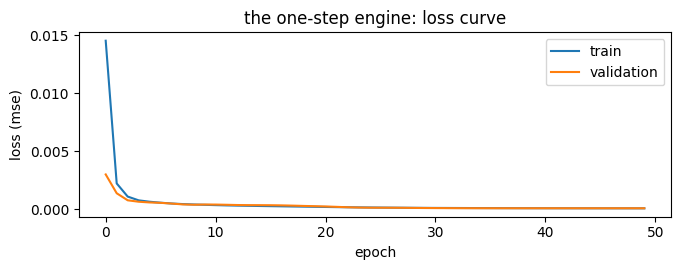

stopped after 50 epochs


one-step LSTM, 1 hour ahead: MAE 33.4 MW


In [3]:
keras.utils.set_random_seed(5509)   # re-seed right before the build, not just at import

one_step = Sequential()
one_step.add(Input(shape=(n_steps, n_features)))
one_step.add(LSTM(32))
one_step.add(Dense(1))
one_step.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = one_step.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 2.8))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("the one-step engine: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print("stopped after", len(history.history["loss"]), "epochs")

pred_1h = sc_y.inverse_transform(one_step.predict(X_test, verbose=0)).ravel()
print(f"one-step LSTM, 1 hour ahead: MAE {mean_absolute_error(y_true, pred_1h):.1f} MW")

## Rolling the one-step model forward

The engine above answers one question: *given the last 24 hours, what is demand in the next hour?* To get a whole
day, run it 24 times - and after the first run, the "last hour" it is given is **its own prediction**.

**We assume a perfect weather forecast in everything below.** That is generous, but it is deliberate: holding the
weather fixed means the only thing changing between the two runs is the demand column, so whatever difference we
see is caused by *that* and nothing else.

Those two runs are:

| run | what goes in the demand column for hours that have not happened |
| :-- | :-- |
| **honest** | the model's own prediction - `future[:, -1] = p` |
| **leaking** | the REAL future demand, which in real life you do not have |

One line of code separates them, and it is the one line worth pausing on.

In [ ]:
def recursive_forecast(model, seqs, n_steps, horizon, mode="honest"):
    """Roll a one-step model horizon steps ahead from EVERY window in seqs.

    Weather and clock columns always come from the real future row (a perfect forecast).
    mode='honest' -> the demand column is filled with OUR OWN prediction. Errors compound.
    mode='leak'   -> the real future demand is left in place. Impossible in practice - it is the
                     cheat we run on purpose so we can measure what the honest version costs."""
    n_orig = len(seqs) - n_steps - horizon + 1

    # every origin's starting window: 24 real hours of history
    window = []
    for i in range(n_orig):
        window.append(seqs[i:i+n_steps])
    window = np.array(window)                                            # (origins, 24, 8)

    preds = np.zeros((n_orig, horizon))
    for h in range(horizon):
        p = model.predict(window, verbose=0).ravel()                     # the next hour, for every origin at once
        preds[:, h] = p

        # the real row for hour +h+1: perfect weather, correct clock
        future = []
        for i in range(n_orig):
            future.append(seqs[i+n_steps+h])
        future = np.array(future).copy()

        if mode == "honest":
            future[:, -1] = p          # <-- THE line. Our guess becomes tomorrow's "history".
        # if mode == "leak" we simply do not touch it, so the true demand rides along

        window = np.concatenate([window[:, 1:, :], future[:, None, :]], axis=1)   # slide the window
    return preds

horizon = 24
rec_honest = recursive_forecast(one_step, te_s, n_steps, horizon, mode="honest")
rec_leak   = recursive_forecast(one_step, te_s, n_steps, horizon, mode="leak")

# the truth for the same origins and horizons
n_orig = rec_honest.shape[0]
truth = []
for i in range(n_orig):
    truth.append(te_s[i+n_steps:i+n_steps+horizon, -1])
truth = np.array(truth)

def to_mw(a):
    """Undo the target scaler, keeping the (origins, horizon) shape."""
    flat = sc_y.inverse_transform(a.reshape(-1, 1))
    return flat.reshape(a.shape)

truth_mw      = to_mw(truth)
rec_honest_mw = to_mw(rec_honest)
rec_leak_mw   = to_mw(rec_leak)

mae_honest = np.abs(rec_honest_mw - truth_mw).mean(axis=0)
mae_leak   = np.abs(rec_leak_mw   - truth_mw).mean(axis=0)
print("honest  (own predictions fed back) - MAE at h=1, 6, 12, 24:", mae_honest[[0, 5, 11, 23]].round(1))
print("leaking (real demand fed back)     - MAE at h=1, 6, 12, 24:", mae_leak[[0, 5, 11, 23]].round(1))

## Error by horizon: watch it fall apart

One number is not enough here. What matters is **how the error grows as the roll-forward gets further from the
last real reading**, so everything is reported per horizon: hour 1, hour 2, ... hour 24.

Both runs get perfect weather. The only difference is the demand column:

- **honest** - the model eats its own predictions, which is what you would actually ship
- **leaking** - the real future demand rides along in the window, which you will never have

Read the table first. The picture underneath says the same thing.

In [5]:
# seasonal naive at every horizon: "the same hour yesterday", scored on the same origins
dem = test["Demand"].values
naive = []
for h in range(horizon):
    actual    = dem[n_steps+h      : n_steps+h      + n_orig]
    yesterday = dem[n_steps+h-24   : n_steps+h-24   + n_orig]
    naive.append(mean_absolute_error(actual, yesterday))
naive = np.array(naive)


In [ ]:
# the table, before the picture
rows = {"honest (own predictions)": mae_honest,
        "leaking (real demand)": mae_leak,
        "seasonal naive": naive}

H = [0, 5, 11, 23]                          # hours 1, 6, 12, 24
board = {}
for name, curve in rows.items():
    board[name] = curve[H].round(1)
board = pd.DataFrame(board, index=["h=1", "h=6", "h=12", "h=24"]).T
display(board)

print()
for name, curve in rows.items():
    grew = curve[23] / curve[0]
    print(name.ljust(26), "h=1:", round(curve[0], 1), " h=24:", round(curve[23], 1),
          "  ->", round(grew, 1), "x worse")

print()
print("the price of feeding the model its own guesses, at hour 24:",
      round(mae_honest[23] - mae_leak[23], 1), "MW")

**That last column is the whole lesson.**

The **leaking** line barely moves. That is not a good model - it is a *cheating* model. With the real demand in
the window it is never actually forecasting 24 hours out; at every horizon it is doing the same easy one-hour-ahead
job it was trained for. If you ever build a multi-step forecast and the error does not grow with the horizon,
this is the first thing to suspect.

The **honest** line climbs, because by hour 24 the window is almost entirely the model's own guesses. The gap
between the two lines is the price of that, in megawatts, and it is the whole reason direct and multi-output
models exist.

Seasonal naive barely moves either, for a completely different reason: "the same hour yesterday" is exactly as
good at hour 24 as at hour 1. That flat line is why it is such a stubborn baseline.

### The same numbers as a picture

Every line is one strategy, every point is one horizon. The lines that climb left to right are the error falling
apart; the flat grey one is the baseline that does not care how far ahead you ask.

In [ ]:
hrs = np.arange(1, horizon + 1)
plt.figure(figsize=(9, 4))
plt.plot(hrs, mae_honest, marker=".", label="honest - the model eats its own predictions")
plt.plot(hrs, mae_leak,   marker=".", ls="--", label="LEAKING - real demand in the window (a cheat)")
plt.plot(hrs, naive, "--", color="gray", label="seasonal naive")
plt.xlabel("hours ahead"); plt.ylabel("test MAE (MW)")
plt.title("What it costs to feed a model its own guesses")
plt.legend(); plt.tight_layout(); plt.show()

## A single forecast day, up close

The table tells you the error grows. This shows you *what that looks like* - one forecast, issued at midnight,
rolling 24 hours forward against the day that actually happened.

In [ ]:
# ONE forecast day, up close: issued at midnight, 24 hours of roll-forward against what happened
origins = test.index[n_steps - 1 : n_steps - 1 + n_orig]     # the hour each forecast was ISSUED
o = origins.get_indexer([pd.Timestamp("2019-07-16 00:00")])[0]

hrs = np.arange(1, horizon + 1)
plt.figure(figsize=(9, 3.5))
plt.plot(hrs, truth_mw[o], "k", lw=2.2, label="actual")
plt.plot(hrs, rec_honest_mw[o], marker=".", label="honest (own predictions)")
plt.plot(hrs, rec_leak_mw[o], marker=".", ls="--", label="leaking (real demand)")
plt.xlabel("hours ahead"); plt.ylabel("MW")
plt.title("Forecast issued " + str(origins[o]))
plt.legend(); plt.tight_layout(); plt.show()

## Four days across the year

One day could be luck. These are four forecasts issued at midnight in four different seasons, each rolled the
full 24 hours. Look for two things: **where in the day** the honest forecast comes apart, and how closely the
leaking version hugs the black line all day long - that is what cheating looks like.

In [ ]:
sample_days = ["2019-01-16", "2019-04-16", "2019-07-16", "2019-10-16"]

fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
ax = ax.ravel()

for panel, day in enumerate(sample_days):
    o = origins.get_indexer([pd.Timestamp(day + " 00:00")])[0]
    a = ax[panel]
    a.plot(hrs, truth_mw[o], "k", lw=2.2, label="actual")
    a.plot(hrs, rec_honest_mw[o], marker=".", ms=4, label="honest")
    a.plot(hrs, rec_leak_mw[o], marker=".", ms=4, ls="--", label="leaking")

    err = np.abs(rec_honest_mw[o] - truth_mw[o]).mean()
    a.set_title(day + "   (honest MAE " + str(round(err)) + " MW)", fontsize=10)
    a.set_ylabel("MW")
    if panel >= 2:
        a.set_xlabel("hours ahead")

ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What to look for.** The honest forecast sits on the black line for the first few hours in every season - that
is the model doing the job it was trained for. The afternoon is where it goes, because that is the furthest from
the last real reading.

The leaking line hugs the truth all day, in every season. It looks like a wonderful model. It is a model that has
been handed the answer.

## Where do the future covariates come from?

The roll-forward forced this question, and it is the real content of the notebook. Every column in the window has
to be filled for hours that have not happened. There are exactly three kinds:

| column | at hour +h you actually have... | what to do |
| :-- | :-- | :-- |
| **calendar / clock** (hour, weekday, holiday) | the exact value - it is a calendar | use it. It is free, and after demand's own past it is the strongest thing you have |
| **weather** (temperature, dew point, humidity) | *not* the actual - only a **forecast** | feed the NWS forecast for hour +h. We assumed a perfect one all notebook; in practice its error becomes yours, so validate against *archived forecasts*, never actuals |
| **the target's own past** (demand) | actuals up to now, then nothing | this is the trap. Honest means your own predictions, and they compound. The leaking run is what it looks like when you get this wrong |

That third row is the whole notebook. Nothing is wrong with the model - it is being asked, by hour 24, to make a
prediction from a window that is almost entirely its own guesses.

**Two honest ways out**, both for a later course: train a separate model for each horizon so nothing is ever fed
back, or give the model a `Dense(24)` head and have it produce the whole day at once. Both appear in the diagram
at the top.

## Save the model and use it again

In [10]:
one_step.save('A5_one_step_engine.keras')
reloaded = load_model('A5_one_step_engine.keras')
print("reloaded model reproduces the forecast:",
      np.allclose(one_step.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0)))

reloaded model reproduces the forecast: True


## On your own

- Roll forward from a **week** of history (`n_steps = 168`) instead of a day. Does the longer window slow the
  error growth, or does the compounding swamp it either way?
- Degrade the weather on purpose: add noise to the future temperature column and watch the honest curve move.
  That is a cheap simulation of a real forecast, and it tells you what weather accuracy is worth to you.
- Forecast **48 hours** instead of 24. Where does the honest curve cross seasonal naive?
- Add a `holiday` column (`pandas.tseries.holiday.USFederalHolidayCalendar`). It is a calendar covariate, so you
  know it perfectly in advance - exactly the free kind from the table above.
- Pick the **worst** forecast day in the test year (largest honest MAE) and plot it next to the best one. What
  was different about that day?